In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

print(os.getcwd())

/Users/kenyaharvey/wine-quality-prediction/notebooks


In [3]:
print(os.listdir("../data"))

['.DS_Store', 'winequality-red.csv']


In [5]:
import os

df = pd.read_csv("../data/winequality-red.csv", sep=";")


In [6]:
print(os.listdir("../data"))


['.DS_Store', 'winequality-red.csv']


In [7]:
import pandas as pd

df = pd.read_csv("../data/winequality-red.csv", sep=";")

df.head()

,"fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id"
0,"7.4,0.7,0,1.9,0.076,11,34,0.9978,3.51,0.56,9.4..."
1,"7.8,0.88,0,2.6,0.098,25,67,0.9968,3.2,0.68,9.8..."
2,"7.8,0.76,0.04,2.3,0.092,15,54,0.997,3.26,0.65,..."
3,"11.2,0.28,0.56,1.9,0.075,17,60,0.998,3.16,0.58..."
4,"7.4,0.7,0,1.9,0.076,11,34,0.9978,3.51,0.56,9.4..."


In [8]:
df.shape

(1143, 1)

In [9]:
sep=";"


In [10]:
import pandas as pd

df = pd.read_csv("../data/winequality-red.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [11]:
df.shape

(1143, 13)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [13]:
df.isnull().sum()


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

## Class Distribution

The original wine quality scores are highly imbalanced, with quality scores of 5 and 6 accounting for approximately 83% of the dataset. Quality scores of 3 and 8 are significantly underrepresented.

To create a more practical classification problem, the quality scores were converted into two classes:

- **Bad quality (0):** quality score below 6
- **Good quality (1):** quality score of 6 or higher.

After this transformation, the dataset contains 522 bad-quality wines (45.7%) and 621 good-quality wines (54.3%), resulting in a relatively balanced binary target.

In [15]:
df["quality"].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

In [17]:
df["quality_label"] = (df["quality"] >= 6).astype(int)

df["quality_label"].value_counts(normalize=True) * 100

quality_label
1    54.330709
0    45.669291
Name: proportion, dtype: float64

In [18]:
df["quality_label"] = (df["quality"] >= 6).astype(int)

## Data Quality Assessment: 

The dataset contains 1,143 observations and 13 columns. No missing values or duplicate rows were identified, and all variables have appropriate numeric data types. The Id column is an identifier rather than a meaningful predictive feature, so it will be excluded from modeling. The quality target is imbalanced, with scores of 5 and 6 representing approximately 83% of observations, while scores of 3 and 8 are rare. To create a more balanced and business-relevant classification problem, quality scores will be converted into binary classes: good quality (≥6) and bad quality (<6).

In [19]:
df = df.drop(columns=["Id"])

In [20]:
df.shape

(1143, 13)

In [21]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'quality_label'],
      dtype='str')

In [22]:
df["quality_label"].value_counts()

quality_label
1    621
0    522
Name: count, dtype: int64

In [25]:
original_df = df.copy()
duplicates = original_df[original_df.duplicated(keep=False)]

print(duplicates.to_string(index=False))

 fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density   pH  sulphates   alcohol  quality  quality_label
           7.4             0.700         0.00            1.90      0.076                 11.0                  34.0  0.99780 3.51       0.56  9.400000        5              0
           7.4             0.700         0.00            1.90      0.076                 11.0                  34.0  0.99780 3.51       0.56  9.400000        5              0
           7.2             0.725         0.05            4.65      0.086                  4.0                  11.0  0.99620 3.41       0.39 10.900000        5              0
           7.2             0.725         0.05            4.65      0.086                  4.0                  11.0  0.99620 3.41       0.39 10.900000        5              0
           8.6             0.490         0.28            1.90      0.110                 20.0                 136.0  0.99720 

In [26]:
print("ERROR:", (original_df.astype(str) == "ERROR").sum().sum())
print("UNKNOWN:", (original_df.astype(str) == "UNKNOWN").sum().sum())

ERROR: 0
UNKNOWN: 0


## Exploratory Data Analysis (EDA)

### Feature Distributions

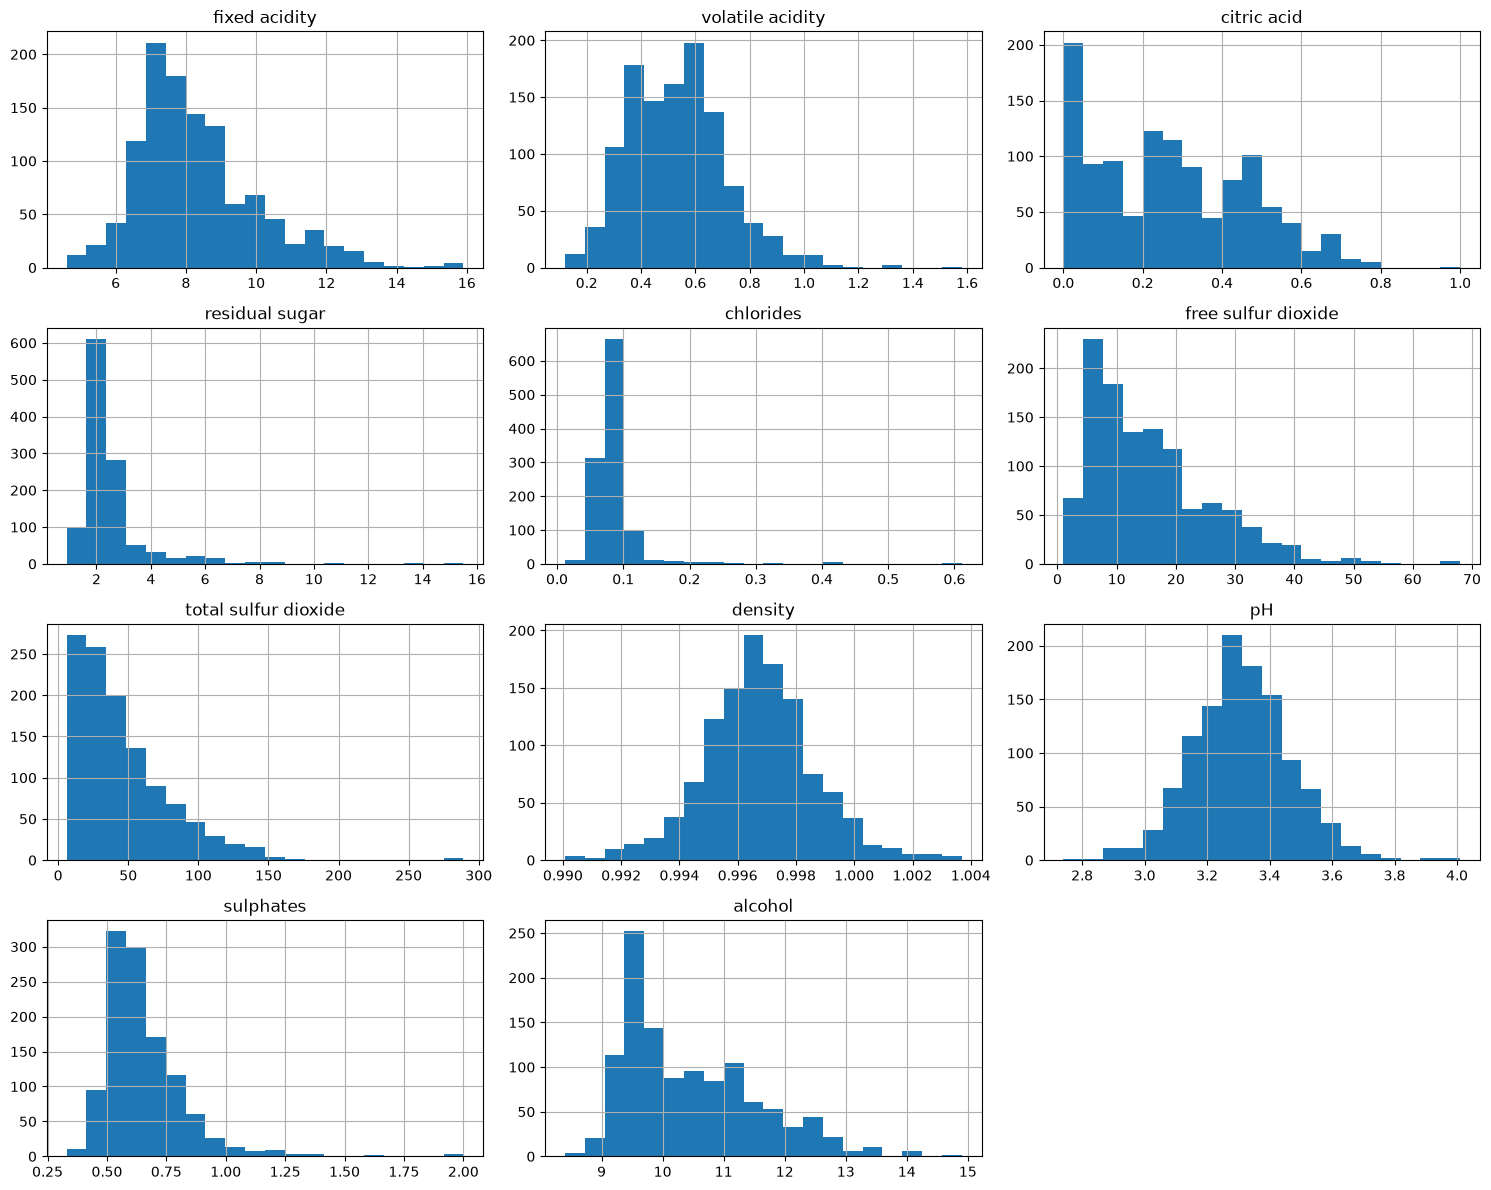

In [27]:
import matplotlib.pyplot as plt

features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

df[features].hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

### Feature Distribution Findings

The chemical features show different distributions and levels of variability. Several features are right-skewed, with most observations concentrated at lower values and a smaller number of observations extending toward higher values. Other features, such as pH, show a more concentrated distribution.

These differences in scale and distribution are important for modeling. Standardization will be applied before training the SGD and SVC models so that features with larger numerical ranges do not disproportionately influence the models.

In [28]:
plt.savefig(
    "../images/feature_distributions.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

### Correlation Analysis

A correlation matrix is used to examine the linear relationships between the physicochemical features and wine quality. This helps identify features that may have stronger relationships with the target and potential relationships between predictor variables.

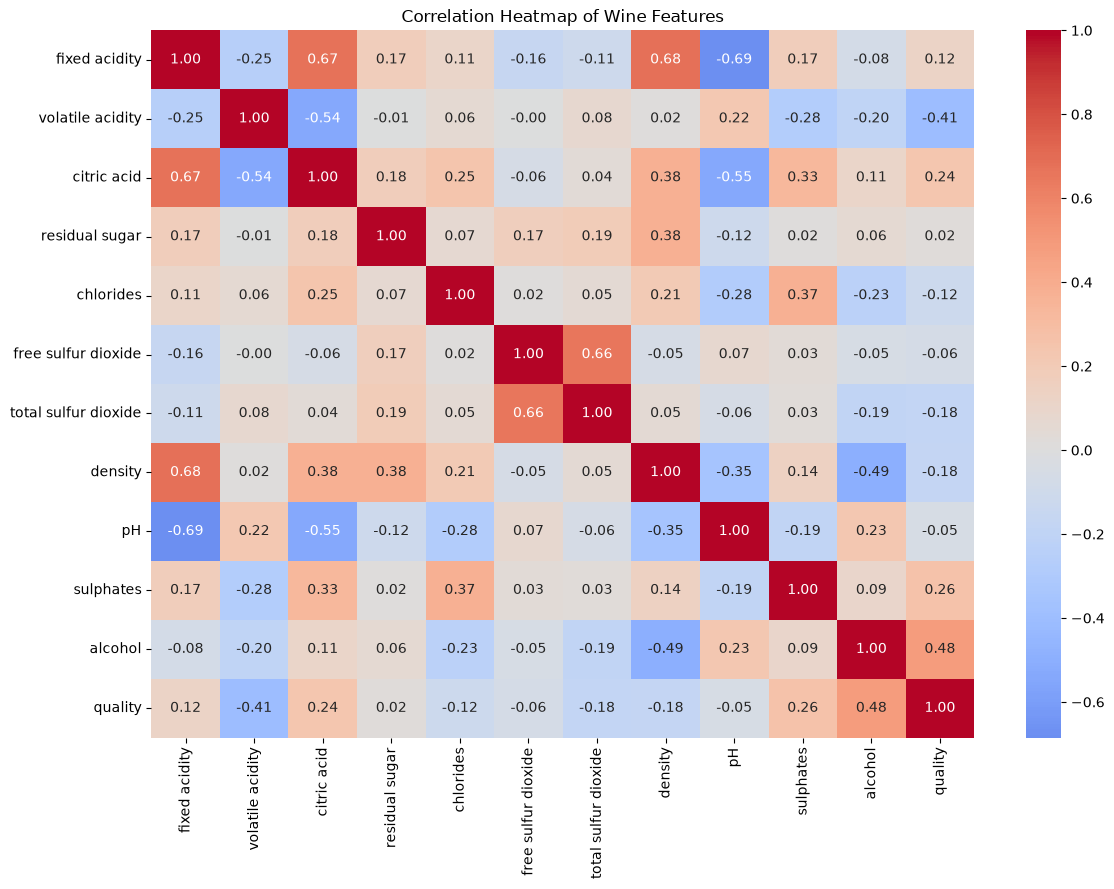

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df[features + ["quality"]].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Wine Features")
plt.tight_layout()
plt.show()

In [30]:
quality_correlations = (
    correlation_matrix["quality"]
    .drop("quality")
    .sort_values(ascending=False)
)

quality_correlations

alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64

### Correlation Findings

The correlation analysis shows that alcohol has the strongest positive linear relationship with wine quality (r = 0.485). This suggests that wines with higher alcohol levels tend to have higher quality scores in this dataset.

Volatile acidity has the strongest negative relationship with quality (r = -0.407), indicating that higher volatile acidity tends to be associated with lower quality scores.

Sulphates (r = 0.258) and citric acid (r = 0.241) show weaker positive relationships with quality. Density (r = -0.175) and total sulfur dioxide (r = -0.183) show weaker negative relationships.

Residual sugar (r = 0.022), pH (r = -0.052), and free sulfur dioxide (r = -0.063) have very weak linear relationships with quality.

These correlations identify potentially useful predictors, but correlation does not establish causation and does not capture nonlinear relationships. Therefore, the classification models will use the full set of physicochemical features rather than selecting features solely based on their correlation with quality.

In [31]:
quality_correlations.abs().sort_values(ascending=False)

alcohol                 0.484866
volatile acidity        0.407394
sulphates               0.257710
citric acid             0.240821
total sulfur dioxide    0.183339
density                 0.175208
chlorides               0.124085
fixed acidity           0.121970
free sulfur dioxide     0.063260
pH                      0.052453
residual sugar          0.022002
Name: quality, dtype: float64

The absolute correlation values confirm that alcohol and volatile acidity have the strongest linear associations with quality, although their directions differ.

In [32]:
plt.savefig(
    "../images/correlation_heatmap.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Train/Test Split

The dataset is divided into training and testing sets so that the classification models can be trained on one portion of the data and evaluated on previously unseen observations.

A stratified split is used to preserve the proportion of good- and bad-quality wines in both the training and testing datasets. This is important because the target classes are not perfectly balanced.

In [33]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["quality", "quality_label"])
y = df["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (914, 11)
Testing set: (229, 11)


### Stratification Check

The training and testing datasets were created using stratified sampling to preserve the proportion of good- and bad-quality wines. The class distributions are compared below to confirm that the split maintained similar proportions across both datasets.

In [34]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training class distribution:
quality_label
1    0.543764
0    0.456236
Name: proportion, dtype: float64

Testing class distribution:
quality_label
1    0.541485
0    0.458515
Name: proportion, dtype: float64


### Stratification Findings

The stratified train/test split successfully preserved the class proportions. Good-quality wines represent 54.38% of the training set and 54.15% of the testing set, while bad-quality wines represent 45.62% and 45.85%, respectively.

The small differences are expected because the datasets contain different numbers of observations. Overall, the class distributions are sufficiently similar for reliable model evaluation.

## Feature Scaling

The chemical features have different numerical ranges. For example, alcohol, acidity, and sulfur dioxide are measured on different scales. Standardization transforms the features so that they have a mean of approximately 0 and a standard deviation of approximately 1.

Scaling is particularly important for the SGD and SVC models because these algorithms are sensitive to feature magnitude. The Random Forest model does not require scaling, but the same standardized feature set will be used for consistency when comparing the classifiers.


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
print("Training scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

Training scaled shape: (914, 11)
Testing scaled shape: (229, 11)


In [37]:
print("Training means:")
print(X_train_scaled.mean(axis=0))

print("\nTraining standard deviations:")
print(X_train_scaled.std(axis=0))

Training means:
[-1.55479811e-17 -1.36044835e-16  9.32878865e-17 -5.05309385e-17
 -3.22620608e-16 -3.01242134e-17  2.38078460e-17  3.09424259e-14
 -2.63538279e-15  1.08835868e-16  8.76517434e-16]

Training standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Feature Scaling Findings

The training features were successfully standardized. The calculated means are effectively zero, with only negligible floating-point differences, and all feature standard deviations equal 1.

The scaler was fitted only on the training data and then applied to the testing data. This prevents information from the testing set from influencing the preprocessing step and helps avoid data leakage.

## Model Training

Three classification algorithms will be trained and compared:

- **Random Forest:** An ensemble of decision trees that can capture nonlinear relationships and interactions between features.
- **Stochastic Gradient Descent (SGD):** A computationally efficient linear classifier that learns through iterative optimization.
- **Support Vector Classifier (SVC):** A classifier that identifies a decision boundary between classes and can model nonlinear relationships through kernels.

The models will be evaluated using the same training and testing datasets to provide a fair comparison.

### Random Forest Classifier

Random Forest is used because it can capture nonlinear relationships between the physicochemical features and wine quality. It also provides feature importance measures that can later be used to identify which chemical properties contribute most to the model's predictions.

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Random Forest Evaluation

The Random Forest model is evaluated on the held-out testing dataset. Accuracy provides an overall measure of correct predictions, while the classification report provides precision, recall, and F1-score for each quality class.

In [39]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))


Random Forest Accuracy: 0.8078602620087336

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.76      0.78       105
           1       0.81      0.85      0.83       124

    accuracy                           0.81       229
   macro avg       0.81      0.80      0.81       229
weighted avg       0.81      0.81      0.81       229



### Random Forest Findings

The Random Forest model achieved an accuracy of 80.8% on the testing dataset. Performance was relatively balanced across the two classes, with an F1-score of 0.78 for bad-quality wines and 0.83 for good-quality wines.

The model identified good-quality wines more effectively, achieving a recall of 85% compared with 76% for bad-quality wines. This indicates that the model missed fewer good-quality wines than bad-quality wines.

Overall, the results suggest that Random Forest provides a strong baseline for predicting the binary wine-quality classification target. However, the SGD and SVC models must also be evaluated before determining which classifier is most suitable.

### Random Forest Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each quality class. It provides a more detailed view of the types of classification errors made by the Random Forest model.

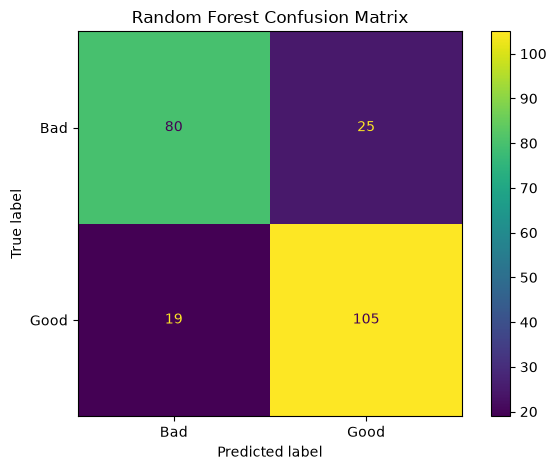

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Bad", "Good"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../images/random_forest_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [41]:
print(rf_cm)

[[ 80  25]
 [ 19 105]]


### Random Forest Confusion Matrix Findings

The confusion matrix shows that the Random Forest correctly classified 80 of the 105 bad-quality wines and 105 of the 124 good-quality wines.

The model incorrectly classified 25 bad-quality wines as good-quality wines and 19 good-quality wines as bad-quality wines. Therefore, the model made more false-positive errors (25) than false-negative errors (19).

This is consistent with the classification report, where recall was higher for good-quality wines (85%) than for bad-quality wines (76%). The model therefore performs somewhat better at identifying good-quality wines than bad-quality wines.

### Stochastic Gradient Descent (SGD) Classifier

The SGD classifier provides a linear classification approach for comparison with the nonlinear Random Forest model. Because SGD is sensitive to feature scale, the standardized training and testing features will be used.

In [42]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    random_state=42
)

sgd_model.fit(X_train_scaled, y_train)

sgd_predictions = sgd_model.predict(X_test_scaled)

print("SGD model trained successfully.")

SGD model trained successfully.


### SGD Evaluation

The SGD classifier is evaluated on the same held-out testing dataset used for the Random Forest model. Accuracy, precision, recall, and F1-score are used to assess its classification performance.

In [43]:
from sklearn.metrics import accuracy_score, classification_report

sgd_accuracy = accuracy_score(y_test, sgd_predictions)

print("SGD Accuracy:", sgd_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, sgd_predictions))

SGD Accuracy: 0.62882096069869

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.38      0.48       105
           1       0.62      0.84      0.71       124

    accuracy                           0.63       229
   macro avg       0.64      0.61      0.60       229
weighted avg       0.64      0.63      0.61       229



### SGD Findings

The SGD classifier achieved an accuracy of 62.9% on the testing dataset, which is substantially lower than the Random Forest accuracy of 80.8%.

The model performed much better at identifying good-quality wines, with a recall of 84%, than bad-quality wines, which had a recall of only 38%. This indicates that the SGD classifier incorrectly classified a substantial number of bad-quality wines as good-quality wines.

The lower F1-score for class 0 (0.48) further demonstrates that the SGD model struggled to identify bad-quality wines. Overall, the SGD classifier provides weaker performance than the Random Forest model on this dataset.

### SGD Confusion Matrix

The confusion matrix is used to examine the types of correct and incorrect predictions made by the SGD classifier and to compare its classification errors with those of the Random Forest model.

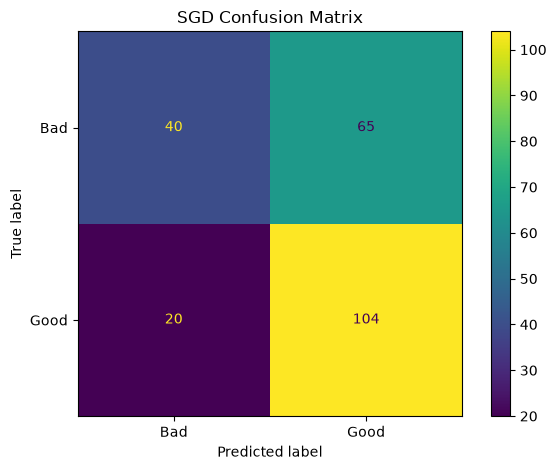

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sgd_cm = confusion_matrix(y_test, sgd_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=sgd_cm,
    display_labels=["Bad", "Good"]
)

disp.plot()

plt.title("SGD Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../images/sgd_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [45]:
print(sgd_cm)

[[ 40  65]
 [ 20 104]]


### SGD Confusion Matrix Findings

The confusion matrix shows that the SGD classifier correctly identified 40 of the 105 bad-quality wines and 104 of the 124 good-quality wines.

However, 65 bad-quality wines were incorrectly classified as good-quality wines, while 20 good-quality wines were incorrectly classified as bad-quality wines. The relatively high number of false-positive predictions for the good-quality class explains the low 38% recall for bad-quality wines.

Compared with the Random Forest model, SGD made substantially more classification errors, particularly by misclassifying bad-quality wines as good-quality wines.

### Support Vector Classifier (SVC)

The Support Vector Classifier is used to provide another comparison with the Random Forest and SGD models. SVC is particularly sensitive to feature scale, so the standardized features will be used for training and prediction.

In [46]:
from sklearn.svm import SVC

svc_model = SVC(
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

svc_predictions = svc_model.predict(X_test_scaled)

print("SVC model trained successfully.")

SVC model trained successfully.


### SVC Evaluation

The Support Vector Classifier is evaluated on the same held-out testing dataset used for the Random Forest and SGD models. Accuracy, precision, recall, and F1-score are used to compare its performance with the other classifiers.

In [47]:
from sklearn.metrics import accuracy_score, classification_report

svc_accuracy = accuracy_score(y_test, svc_predictions)

print("SVC Accuracy:", svc_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, svc_predictions))

SVC Accuracy: 0.7860262008733624

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.75      0.76       105
           1       0.80      0.81      0.80       124

    accuracy                           0.79       229
   macro avg       0.78      0.78      0.78       229
weighted avg       0.79      0.79      0.79       229



### SVC Findings

The SVC model achieved an accuracy of 78.6% on the testing dataset. Its performance was relatively balanced across the two quality classes, with an F1-score of 0.76 for bad-quality wines and 0.80 for good-quality wines.

The model achieved a recall of 75% for bad-quality wines and 81% for good-quality wines. Compared with the SGD classifier, SVC provides substantially stronger and more balanced classification performance.

However, its overall accuracy and F1-scores are slightly lower than those of the Random Forest model, indicating that Random Forest currently provides the stronger overall performance.

### SVC Confusion Matrix

The confusion matrix provides a detailed view of the correct and incorrect predictions made by the SVC model. This allows the types of classification errors to be compared with those produced by Random Forest and SGD.

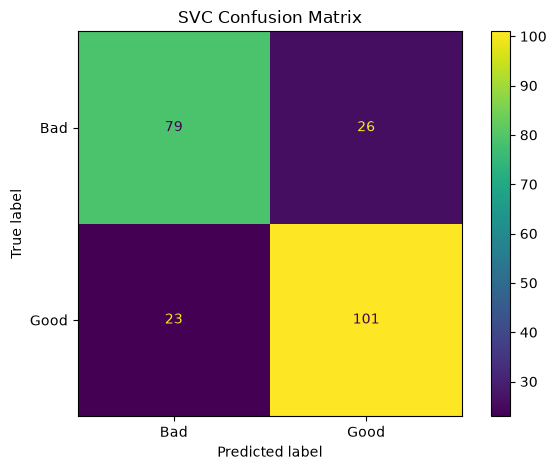

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

svc_cm = confusion_matrix(y_test, svc_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=svc_cm,
    display_labels=["Bad", "Good"]
)

disp.plot()

plt.title("SVC Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../images/svc_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [49]:
print(svc_cm)

[[ 79  26]
 [ 23 101]]


### SVC Confusion Matrix Findings

The confusion matrix shows that the SVC model correctly classified 79 of the 105 bad-quality wines and 101 of the 124 good-quality wines.

The model incorrectly classified 26 bad-quality wines as good-quality wines and 23 good-quality wines as bad-quality wines. The relatively similar number of errors between the two classes indicates that SVC produced a relatively balanced pattern of classification errors.

Overall, SVC performed substantially better than SGD but slightly below Random Forest based on accuracy and class-level F1-scores.

## Random Forest Feature Importance

Random Forest provides a feature importance measure that estimates the relative contribution of each predictor to the model's decision-making process. This analysis helps identify which physicochemical properties were most influential in predicting wine quality.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

alcohol                 0.197655
sulphates               0.133869
total sulfur dioxide    0.102607
volatile acidity        0.100041
density                 0.083613
chlorides               0.070140
fixed acidity           0.069547
pH                      0.067561
free sulfur dioxide     0.060627
citric acid             0.059321
residual sugar          0.055017
dtype: float64


### Feature Importance Findings

The Random Forest model identified alcohol as the most influential predictor, accounting for approximately 19.8% of the model's total feature importance. Sulphates was the second most influential feature at approximately 13.4%, followed by total sulfur dioxide (10.3%), volatile acidity (10.0%), and density (8.4%).

The importance results are generally consistent with the earlier correlation analysis, where alcohol and volatile acidity showed the strongest linear relationships with wine quality. However, Random Forest feature importance captures a feature's contribution to the model's predictive decisions and can account for nonlinear relationships and interactions that simple correlation does not capture.

Feature importance should therefore be interpreted as an indication of predictive contribution rather than evidence that a feature causes higher or lower wine quality.

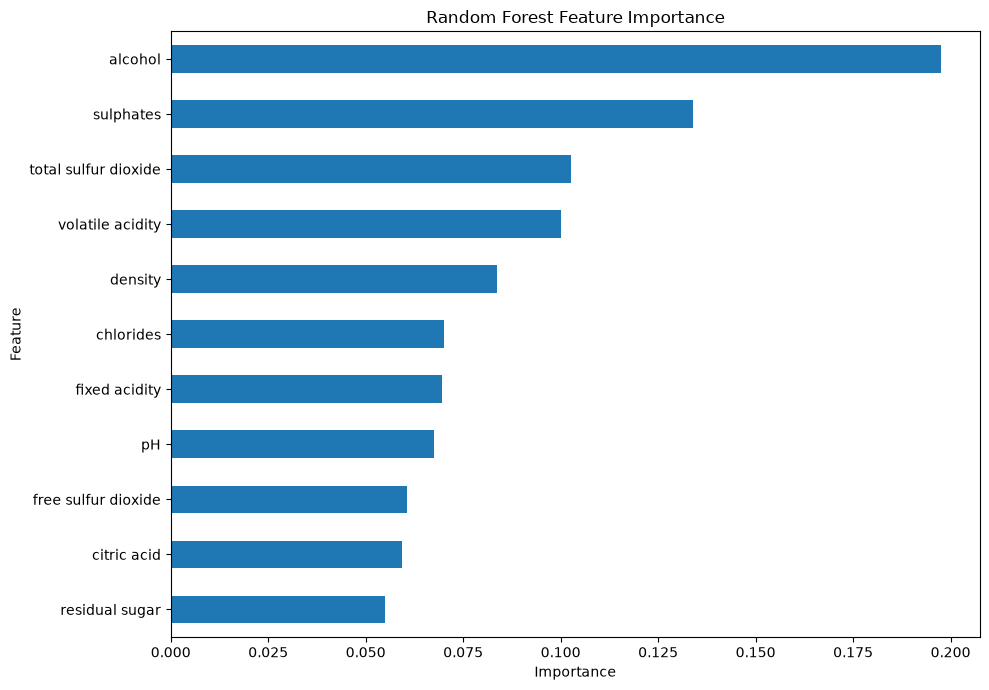

In [51]:
import matplotlib.pyplot as plt

feature_importance.sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "../images/random_forest_feature_importance.png",
    bbox_inches="tight"
)

plt.show()

## Model Comparison

The three classification models are compared using their test-set accuracy, precision, recall, and F1-score. Comparing the models using multiple evaluation metrics provides a more complete assessment than accuracy alone, particularly because the goal is to correctly identify both good- and bad-quality wines.

In [53]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "SGD", "SVC"],
    "Accuracy": [rf_accuracy, sgd_accuracy, svc_accuracy],
    "Bad F1": [0.78, 0.48, 0.76],
    "Good F1": [0.83, 0.80, 0.80]
})

comparison_display = comparison.copy()

comparison_display["Accuracy"] = (
    comparison_display["Accuracy"] * 100
).round(1)

comparison_display["Bad F1"] = (
    comparison_display["Bad F1"] * 100
).round(1)

comparison_display["Good F1"] = (
    comparison_display["Good F1"] * 100
).round(1)

print(comparison_display.to_string(index=False))

        Model  Accuracy  Bad F1  Good F1
Random Forest      80.8    78.0     83.0
          SGD      62.9    48.0     80.0
          SVC      78.6    76.0     80.0


### Model Comparison Findings

The Random Forest model achieved the highest overall accuracy at 80.8%, followed by SVC at 78.6% and SGD at 62.9%.

Random Forest also produced the strongest F1-scores for both classes, with an F1-score of 0.78 for bad-quality wines and 0.83 for good-quality wines. SVC performed slightly lower, while SGD had substantially weaker performance, particularly for bad-quality wines.

Overall, Random Forest provided the best balance of accuracy and class-level performance among the three classifiers tested.

## Conclusion and Deployment Recommendation

### Conclusion

Three classification models were trained and evaluated to predict whether a wine should be classified as good or bad based on its physicochemical properties.

Random Forest achieved the best overall performance, with a test accuracy of 80.8% and F1-scores of 0.78 for bad-quality wines and 0.83 for good-quality wines. SVC was the second-best performing model, achieving 78.6% accuracy with F1-scores of 0.76 and 0.80. SGD performed substantially worse, with an accuracy of 62.9% and a particularly low F1-score of 0.48 for bad-quality wines.

Based on these results, Random Forest is the most suitable model for this project. It provided the highest accuracy and strongest overall F1-score performance while maintaining relatively balanced classification performance between the two classes. It also provides feature importance information, which improves model interpretability by showing which physicochemical properties contributed most to its predictions.

Alcohol was the most influential feature in the Random Forest model, followed by sulphates, total sulfur dioxide, volatile acidity, and density.

However, the model should not be considered production-ready based solely on these results. Further validation, hyperparameter tuning, cross-validation, and testing on new wine samples would be recommended before deployment. In addition, the consequences of false-positive and false-negative predictions should be considered when determining the appropriate decision threshold for a real-world application.